# **Week - 4**
## Part 1: Warmup Exercises

In [3]:
import os
os.makedirs("outputs", exist_ok=True)

In [4]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cpu
PyTorch version:     2.11.0+cpu
TorchVision version: 0.26.0+cpu


## PyTorch Tensors
### Tensor Question 1

In [5]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, t in [("a", a), ("b", b), ("c", c)]:
    print(f"Tensor {name}:")
    print(f"  Value:  {t}")
    print(f"  Shape:  {t.shape}")
    print(f"  Dtype:  {t.dtype}")
    print(f"  Device: {t.device}")
    print()

# These tensors are on the CPU by default.
# In a training loop on GPU, model weights and input tensors MUST be on the
# same device. PyTorch cannot perform operations between tensors on different
# devices (e.g., one on CPU and one on GPU). If they don't match, you'll get
# a runtime error. Moving both to GPU also enables the parallel computation
# that makes training fast.

Tensor a:
  Value:  tensor([[1., 2., 3.],
        [4., 5., 6.]])
  Shape:  torch.Size([2, 3])
  Dtype:  torch.float32
  Device: cpu

Tensor b:
  Value:  tensor([[0., 0., 0.],
        [0., 0., 0.]])
  Shape:  torch.Size([2, 3])
  Dtype:  torch.float32
  Device: cpu

Tensor c:
  Value:  tensor([1., 1., 1., 1.])
  Shape:  torch.Size([4])
  Dtype:  torch.float32
  Device: cpu



### Tensor Question 2: 

In [6]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

# 1. Compute and print the element-wise square root using torch.sqrt()
sqrt_x = torch.sqrt(x)
print(f"Square root: {sqrt_x}")

# 2. Compute and print the sum using .sum()
sum_x = x.sum()
print(f"Sum: {sum_x}")

# 3. Compute and print the mean using .mean()
mean_x = x.mean()
print(f"Mean: {mean_x}")

# 4. Find and print the index of the maximum value using .argmax()
argmax_x = x.argmax()
print(f"Argmax: {argmax_x}")

# .argmax() returns the INDEX of the largest value, not the value itself.
# In a classifier that outputs scores for 1,000 classes, .argmax() gives you
# the index of the class with the highest score — i.e., the model's predicted
# class label. You then use that index to look up the human-readable class name from a labels list.

Square root: tensor([1., 2., 3., 4., 5.])
Sum: 55.0
Mean: 11.0
Argmax: 4


### Tensor Question 3: 

In [7]:
# Move tensor a from Question 1 to the GPU
a_gpu   = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

#  bring it back to CPU and convert it to a NumPy array
a_back = a_gpu.cpu()
a_numpy = a_back.numpy()
print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# PyTorch requires .cpu() before .numpy() because NumPy only works
# with CPU memory — it has no concept of GPU memory. NumPy arrays always live
# in regular system RAM (CPU). GPU tensors live in VRAM on the graphics card,
# which NumPy cannot access. So PyTorch forces you to explicitly move the data
# back to CPU first. This also means that any time you need to use NumPy-based
# tools (matplotlib, scikit-learn, pandas, etc.) on model outputs, you must
# first detach from the computation graph and move to CPU


a_gpu device: cpu
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


### Tensor Question 4:

In [8]:
t = torch.arange(24).float()
print(f"Original: Shape={t.shape}")  # (24,)

# 1. Reshape to (4, 6)
t1 = t.reshape(4, 6)
print(f"\nReshaped to (4, 6): Shape={t1.shape}")

# 2. Reshape to (2, 3, 4)
t2 = t.reshape(2, 3, 4)
print(f"\nReshaped to (2, 3, 4): Shape={t2.shape}")

# 3. Add a new dimension at position 0
t3 = t1.unsqueeze(0)
print(f"\nAfter unsqueeze(0): Shape={t3.shape}")  # (1, 4, 6)

# A single image has shape (channels, height, width). But neural networks expect a BATCH of images with shape
# (batch_size, channels, height, width). When processing one image at a time, you use
# .unsqueeze(0) to add a batch dimension of size 1 at position 0, turning
# (channels, height, width) into (batch_size, channels, height, width). This matters because the model's
# layers (convolutions, batch norm, etc.) are designed to operate on 4D
# tensors. Passing a 3D tensor without the batch dimension will cause a
# shape mismatch error.

Original: Shape=torch.Size([24])

Reshaped to (4, 6): Shape=torch.Size([4, 6])

Reshaped to (2, 3, 4): Shape=torch.Size([2, 3, 4])

After unsqueeze(0): Shape=torch.Size([1, 4, 6])


### Tensor Question 5:

In [9]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

# 1. Compute the matrix product using NumPy and print the result.
np_result = np.matmul(np_a, np_b)
print(f"\nNumPy result:\n{np_result}")

# 2. Compute the same product using PyTorch and print the result.
torch_result = torch.matmul(t_a, t_b)
print(f"\nPyTorch result:\n{torch_result}")

# 3. Confirm the outputs match.
match = np.allclose(np_result, torch_result.numpy())
print(f"\nResults match: {match}")

# Matrix multiplication is THE core operation in a neural network layer.
# When data passes through a layer, the input vector is multiplied by the layer's
# This is how the network combines and transforms features. Each layer's weight
# matrix holds the learned parameters that determine what patterns the layer
# detects. On a GPU, these matrix multiplications run massively in parallel,
# which is why GPUs are so well-suited for deep learning.


NumPy result:
[[19. 22.]
 [43. 50.]]

PyTorch result:
tensor([[19., 22.],
        [43., 50.]])

Results match: True


## Pretrained Models

### Model Question 1

In [10]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"\nTrainable parameters: {trainable_params:,}")


# ResNet18 has arrox 11.7 million parameters. Training it from scratch took
# ~1.2 million labeled ImageNet images and days of multi-GPU compute. That
# represents enormous cost in data collection, labeling, and hardware time.
# Starting from pretrained weights lets you skip all of that. You get a model
# that already knows how to detect edges, textures, shapes, and objects —
# ready to use for inference immediately, or fine-tuned on your specific task
# with a tiny fraction of the data and compute. For most teams on a deadline
# or budget, training from scratch is simply not an option. Pretrained models
# are the practical default.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\anuja/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.1MB/s]


Total parameters:     11,689,512

Trainable parameters: 11,689,512


### Model Question 2

In [11]:
print(model)

# 1. What is the name of the final layer in ResNet18, and what is its output size? 
#(This number is the total count of ImageNet categories the model can predict.)

# Ans:
# The final layer is named "fc" (fully connected). It is a Linear
# layer with output size 1000
# (fc): Linear(in_features=512, out_features=1000, bias=True)

# 2. Can you identify the blocks named layer1 through layer4? These are the "deep" part of the network — the feature extractor. 
# In plain terms, what does it mean for a network to be "deep"?

# Ans:
# Yes, Layer1, layer2, layer3, and layer4 are clearly visible in the output.
# Each contains BasicBlock sub-modules with Conv2d, BatchNorm2d,
# and ReLU layers. These four layer groups form the feature extractor — the
# "deep" part of the network.
# "Deep" simply means the network has MANY layers stacked sequentially. Data
# passes through one layer after another, and each layer builds on the output
# of the previous one.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Question 3:

In [12]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# 1. What does .to(device) do, and why does it need to match the device your input tensors will be on?

# Ans:
# .to(device) moves ALL of the model's parameters (weights and biases) to the
# specified device — in our case, the GPU ("cuda"). This is necessary because
# PyTorch requires tensors involved in the same operation to be on the same
# device. 

# 2. What does model.eval() change about the model's behavior? 
# Name at least one layer type that behaves differently in training mode vs. evaluation mode.

# Ans:
# .eval() switches the model from training mode to evaluation (inference) mode.
# This changes the behavior of certain layer types:
#
# 1. BatchNorm2d: In training mode, it computes batch statistics (mean/variance)
#    from the current mini-batch. In eval mode, it uses the fixed running
#    statistics learned during training — giving consistent predictions.
#
# 2. Dropout: In training mode, it randomly zeroes some activations to prevent
#    overfitting. In eval mode, dropout is disabled — all neurons contribute to
#    the output, giving you the model's full prediction.
#

Model ready for inference.


### Model Question 4:

In [13]:
preprocess = weights.transforms()
print(preprocess)

# 1. What does the resize/crop step accomplish?
# Ans:
# resize_size=[256]
# Resizes the image so its shorter side is 256 pixels

# crop_size=[224]
# Crops a 224×224 square from the center of the resized image.

# 2. What does ToTensor() do to the pixel value range?
# Ans:
# It Converts the PIL image (pixel values 0–255, shape H×W×C) into a PyTorch
# tensor (pixel values 0.0–1.0, shape C×H×W). 

# 3. What is normalization doing, and why does it use ImageNet's specific mean and 
# standard deviation values rather than, say, mean=0.5, std=0.5?
# Ans:
# mean=[0.485, 0.456, 0.406]
# std=[0.229, 0.224, 0.225]
# For each color channel (Red, Green, Blue), it centers the pixel values
# around zero by subtracting the mean and scaling by the std.
#
# Why these specific numbers? They are the average color values of all
# 1.2 million ImageNet photos. The model was trained seeing images
# preprocessed with THESE exact numbers. If you use different numbers
# at prediction time, it's like the model is looking through tinted
# glasses — colors look "off" and predictions go wrong.


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [14]:
import torch
import random
from pathlib import Path
from PIL import Image

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [15]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


### Inference Question 1

In [16]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    input_tensor = preprocess(image).unsqueeze(0).to(device)


    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
    probs = torch.nn.functional.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    return results

In [17]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


# The top prediction likely makes sense — ImageNet doesn't have a "mountain"
# class directly, but includes related categories like "alp", "valley", "volcano",
# "lakeside", or "cliff". These labels map well onto mountain scenes since mountains
# often appear alongside alpine landscapes, valleys, and lakes.

IndexError: Cannot choose from an empty sequence

### Inference Question 2

In [ ]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# Most confident: "mountain" (0.72 for "valley") and "glacier" (0.72 for "alp")
# — these have clear, simple scenery (snow, peaks, sky) that the model recognizes easily.
#
# Least confident: "forest" (only 0.07 for "stone wall" — the model is basically
# guessing wrong here!) and "buildings" (0.29 for "palace" — spread across many options).
#
# "sea" is interesting — the model is split between "seashore" and "lakeside"
# (both around 0.35). It sees water but can't decide what kind.
#
# Pattern: When a scene has one dominant feature (mountains, ice), the model is
# confident. When a scene is busy or ambiguous (streets with many objects, forests
# with mixed textures), the model spreads its confidence thin or picks the wrong thing.
#
# Surprising: the forest image got "stone wall" as its top pick — the model
# completely missed it. This shows that even a strong pretrained model can fail
# when the image doesn't look like typical ImageNet training examples.


[buildings]  22810.jpg
  palace                          0.2930
  monastery                       0.1951
  castle                          0.1165

[forest]  23441.jpg
  stone wall                      0.0684
  worm fence                      0.0532
  barn                            0.0490

[glacier]  24115.jpg
  alp                             0.7151
  valley                          0.0614
  cliff                           0.0510

[mountain]  20974.jpg
  valley                          0.7217
  alp                             0.1105
  mountain tent                   0.0265

[sea]  20382.jpg
  seashore                        0.3659
  lakeside                        0.3546
  promontory                      0.0723

[street]  22898.jpg
  street sign                     0.2591
  traffic light                   0.2303
  streetcar                       0.1421


### Inference Question 3

In [ ]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")


# why do neural networks output logits internally rather than probabilities? 
# Ans:
# - They can be any number (negative, zero, positive) which is easier for the
#   math inside the network to work with during training.
# - The loss function used in training (CrossEntropyLoss) expects logits and
#   applies softmax internally — this is more numerically stable than doing
#   softmax separately (avoids tiny numbers causing math errors).


# In a production pipeline that needs to filter out low-confidence predictions, 
# which representation would you work with — logits or probabilities — and why?
# Ans:
# For a production pipeline filtering low-confidence predictions:
# Use PROBABILITIES, not logits. Probabilities are between 0 and 1 and are
# easy to interpret — you can set a simple threshold like "only accept
# predictions with probability > 0.7." Logits don't have a fixed scale, so
# a logit of 5.0 means nothing without context. Probabilities give you a
# clear, human-understandable confidence score.

Logit  range: min=-4.84, max=7.08
Prob   range: min=0.000001, max=0.1689
Probs sum to: 1.000000
Top prediction: worm fence  (0.1689)


### Inference Question 4

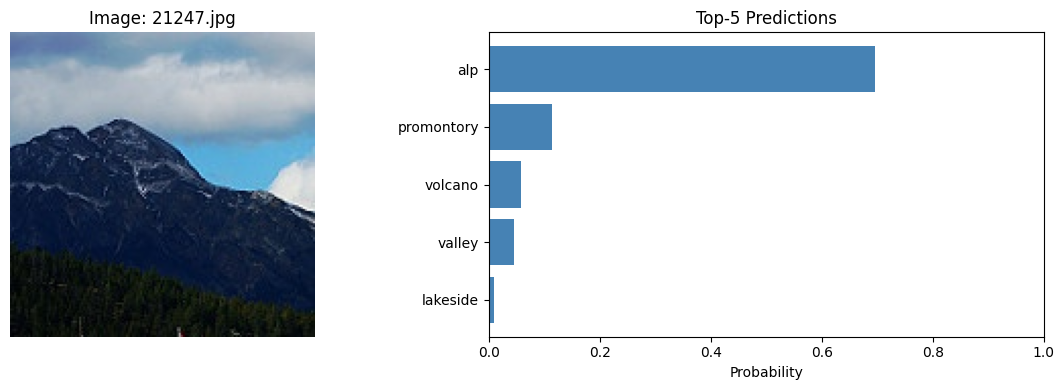

Saved to outputs/warmup_inference_viz.png


In [ ]:
# Load an image and get predictions
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

# Create side-by-side visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: the image
ax1.imshow(img)
ax1.set_title(f"Image: {img_name}")
ax1.axis("off")

# Right panel: horizontal bar chart of top-5 predictions
class_names = [p[0] for p in preds]
probabilities = [p[1] for p in preds]

# Reverse so highest probability is at the top
ax2.barh(class_names[::-1], probabilities[::-1], color="steelblue")
ax2.set_xlabel("Probability")
ax2.set_title("Top-5 Predictions")
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved to outputs/warmup_inference_viz.png")

# For a non-technical dashboard, I would:
# - Use color coding: green bar if top-1 prob > 0.7 (confident), yellow if
#   0.4–0.7 (uncertain), red if < 0.4 (low confidence / needs human review)
# - Show only the top-3 predictions (less clutter)
# - Add a simple label like "HIGH CONFIDENCE" or "NEEDS REVIEW" in plain English
# - Hide probabilities as decimals, show as percentages instead (72% not 0.72)
#
# Threshold: I'd use ~0.5 to 0.7 for the top-1 probability as the "confident
# enough" cutoff. Below that, the prediction goes to a human reviewer.
# The exact threshold depends on the cost of being wrong — for low-risk tasks
# (photo tagging) you can accept 0.5, for high-risk tasks (medical imaging)
# you'd want 0.9+.